### Importar historico de preços de ativos Forex

### Imports

In [1]:
import MetaTrader5 as mt5
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model      import LinearRegression
from statsmodels.tsa.stattools import adfuller
#import quiz_tests

In [2]:
# Initializing MT5 connection 
#if not mt5.initialize(path="D:\\programs\\metatrader\\modal\\terminal64.exe"): # producao modal
#if not mt5.initialize(path="D:\\programs\\metatrader\\desen\\terminal64.exe", portable=True): # desen modal
# if not mt5.initialize(path="D:\\programs\\metatrader\\modal\\terminal64.exe", portable=True): # produ modal
if not mt5.initialize(path="D:\\programs\\mt5\\desen\\terminal64.exe", portable=True): # desen forex
    print("initialize() failed, error code =",mt5.last_error())
    quit()
    
print("MetaTrader5 terminal_info():", mt5.terminal_info())
print("MetaTrader5 version()      :", mt5.version()      )

MetaTrader5 terminal_info(): TerminalInfo(community_account=True, community_connection=True, connected=True, dlls_allowed=False, trade_allowed=True, tradeapi_disabled=False, email_enabled=False, ftp_enabled=False, notifications_enabled=False, mqid=False, build=4260, maxbars=100000, codepage=1252, ping_last=199953, community_balance=9.995246, retransmission=0.4119464469618949, company='MetaQuotes Software Corp.', name='MetaTrader 5', language='Portuguese (Brazil)', path='D:\\programs\\mt5\\desen', data_path='D:\\programs\\mt5\\desen', commondata_path='C:\\Users\\marco\\AppData\\Roaming\\MetaQuotes\\Terminal\\Common')
MetaTrader5 version()      : (500, 4260, '22 Mar 2024')


In [3]:
#obtendo os dados do símbolos na corretora...
import re
def get_symbol_info():
    # obtemos todos os símbolos
    symbols=mt5.symbols_get()
    qtd_symb = len(symbols)
    count=0

    vals = []
    cols = []
    for s in symbols:
        count+=1
        #if count > 3: break
        #print("Importando {} {}/{}".format(s.name, count, qtd_symb))

        # exibimos as propriedades do símbolo como uma lista
        symbol_info_dict = s._asdict()
        if count==1: 
            cols = symbol_info_dict.keys()
            print(cols)
        vals.append(symbol_info_dict.values() )
    
    # criando coluna extra com a categoria...
    dfs = pd.DataFrame(data=vals,columns=cols)
    dfs["categ"] = dfs["path"].str.split("\\").str.get(0)
    
    # eliminando a coluna com path...
    dfs.drop(["path","page","session_volume","session_interest"], axis=1, inplace=True)
    
    for col in dfs.columns:
        if dfs[col].max() == dfs[col].min():
            print("Elimanado a coluna ", col, " tipo:", dfs[col].dtype, " max:", dfs[col].max(), " min:", dfs[col].min())
            dfs.drop([col], axis=1, inplace=True)
    
    #for col in dfs.columns:
    #    print(dfs[col].dtype)
    
    return dfs


In [4]:
# !pip install openpyxl

In [5]:
# obtendo os dados de simbolos na corretora...
dfs = get_symbol_info()
dfs.head()

# salvamos as propriedades dos simbolos em uma planilha
dfs.to_excel("symbols_forex.xlsx")
#dfs = pd.read_excel("symbols_b3.xlsx")

dict_keys(['custom', 'chart_mode', 'select', 'visible', 'session_deals', 'session_buy_orders', 'session_sell_orders', 'volume', 'volumehigh', 'volumelow', 'time', 'digits', 'spread', 'spread_float', 'ticks_bookdepth', 'trade_calc_mode', 'trade_mode', 'start_time', 'expiration_time', 'trade_stops_level', 'trade_freeze_level', 'trade_exemode', 'swap_mode', 'swap_rollover3days', 'margin_hedged_use_leg', 'expiration_mode', 'filling_mode', 'order_mode', 'order_gtc_mode', 'option_mode', 'option_right', 'bid', 'bidhigh', 'bidlow', 'ask', 'askhigh', 'asklow', 'last', 'lasthigh', 'lastlow', 'volume_real', 'volumehigh_real', 'volumelow_real', 'option_strike', 'point', 'trade_tick_value', 'trade_tick_value_profit', 'trade_tick_value_loss', 'trade_tick_size', 'trade_contract_size', 'trade_accrued_interest', 'trade_face_value', 'trade_liquidity_rate', 'volume_min', 'volume_max', 'volume_step', 'volume_limit', 'swap_long', 'swap_short', 'margin_initial', 'margin_maintenance', 'session_volume', 'sess

In [6]:
# obtendo os filtros em uma planilha da B3 com os simbolos cujo volume de trades no dia eh maior que 10mil.
#dffilter = pd.read_excel("TradeInformationConsolidatedFile.xlsx")
#dffilter = pd.read_csv("TradeInformationConsolidatedFile.csv",sep=";")

# simbolos que serao efetivamente processados
#dffilter = pd.read_excel("filtro.xlsx",sep=";") #filtro.xls contem os simbolos que queremos importar
#dfs = dfs[ dfs["name"].isin(dffilter["ticker"]) ] 

# simbolos que serao efetivamente processados
# dffilter = pd.read_excel("filtro-20220709-acoes.xlsx") #filtro.xls contem os simbolos que queremos importar
# dfs = dfs[ dfs["name"].isin(dffilter["TckrSymb"]) ] 

# simbolos que tem o valor ask
dfs = dfs[ dfs["ask"]>0 ]
dfs = dfs[ dfs["name"] != "USDGEL" ]
dfs = dfs[ dfs["name"] != "USDCLP" ]
dfs = dfs[ dfs["name"] != "USDCOP" ]
dfs = dfs[ dfs["name"] != "USDRUB" ]
dfs = dfs[ dfs["name"] != "USDRUR" ]
dfs = dfs[ dfs["name"] != "USDARS" ]
dfs

,select,visible,time,digits,spread,spread_float,ticks_bookdepth,trade_calc_mode,trade_mode,trade_stops_level,...,session_close,margin_hedged,price_change,category,currency_base,currency_profit,currency_margin,description,name,categ
0,True,True,1712231140,5,1,True,10,0,4,0,...,1.08361,100000.0,0.1883,,EUR,USD,EUR,Euro vs US Dollar,EURUSD,Forex
1,True,True,1712231136,5,3,True,10,0,4,0,...,1.26514,100000.0,0.0680,,GBP,USD,GBP,Pound Sterling vs US Dollar,GBPUSD,Forex
2,True,True,1712231141,5,5,True,10,0,4,0,...,0.90279,100000.0,0.3633,,USD,CHF,USD,US Dollar vs Swiss Franc,USDCHF,Forex
3,True,True,1712231142,3,5,True,10,0,4,0,...,151.67700,100000.0,0.0356,,USD,JPY,USD,US Dollar vs Yen,USDJPY,Forex
4,True,True,1712231141,5,171,True,32,0,4,0,...,7.24769,100000.0,-0.0189,,USD,CNH,USD,US Dollar vs Chinese Yuan,USDCNH,Forex
6,True,True,1712231137,5,6,True,10,0,4,0,...,0.65641,100000.0,0.4829,,AUD,USD,AUD,Australian Dollar vs US Dollar,AUDUSD,Forex
7,True,True,1712231134,5,12,True,10,0,4,0,...,0.60090,100000.0,0.4310,,NZD,USD,NZD,New Zealand Dollar vs US Dollar,NZDUSD,Forex
8,True,True,1712231135,5,6,True,10,0,4,0,...,1.35255,100000.0,-0.1420,,USD,CAD,USD,US Dollar vs Canadian Dollar,USDCAD,Forex
9,True,True,1712231138,5,300,True,10,0,4,0,...,10.63923,100000.0,-0.2289,,USD,SEK,USD,US Dollar vs Swedish Krona,USDSEK,Forex


In [7]:
def get_simbols_com_volume_ateh(planilha_TradeInformationConsolidatedFile, TradQty, SgmtNm):
    """
    Leh a planilha de informacoes consolidadas da B3 em formato csv, 
    filtra segundo a quantidade de trades no dia e o nome do segmento
    retorna um Dataframe com o simbolo na coluna TckrSymb
    
    Parameters
    ----------
    planilha_TradeInformationConsolidatedFile : string
        Nome da planilha B3 com a informacao de negociacoes consolidadas
    TradQty : int
        [filtro] Quantidade minima de negociacoes no dia.
    SgmtNm : string
        [filtro] Nome do segmento cujos ativos queremos selecionar
    
    Returns
    -------
    df_symbols : DataFrame
        Dataframe com os simbolos selecionados
    """
    df_symbols = pd.read_csv(planilha_TradeInformationConsolidatedFile, sep=";",decimal=",",thousands=".")
    return df_symbols

In [8]:
df = get_simbols_com_volume_ateh("TradeInformationConsolidatedFile_20220706_1.csv", 10000, "CASH")
#df
df_mask=df[' TradQty ']>10000 and 
df = df[df_mask]
df

SyntaxError: invalid syntax (3984735057.py, line 3)

In [18]:
#df.columns
df[' TradQty ']

0        5901920.0
1        1243008.0
2          81786.0
3          62416.0
4          61161.0
           ...    
40379          NaN
40380          NaN
40381          NaN
40382          NaN
40383          NaN
Name:  TradQty , Length: 40384, dtype: float64

In [9]:
# retornamos um dataframe com os preços do ativo desde a data informada... 
def get_ticker_data(symbol,ano,mes,dia,qtd,timeframe=mt5.TIMEFRAME_D1):
    symbol_info=mt5.symbol_info(symbol)
    if symbol_info!=None:
        
        # importamos o módulo pytz para trabalhar com o fuso horário
        import pytz        # definimos o fuso horário como UTC
        timezone = pytz.timezone("Etc/UTC")

        dt = datetime(ano, mes, dia, tzinfo=timezone)
        # recebemos qtd barras de symbol a partir de dt no fuso horário UTC. As barras contam desde dt pra tras
        rates = mt5.copy_rates_from(symbol, timeframe, dt, qtd)
        # a partir dos dados recebidos criamos o DataFrame
        rates_frame = pd.DataFrame(rates)
        # convertemos o tempo em segundos para o formato datetime
        rates_frame['time']=pd.to_datetime(rates_frame['time'], unit='s')
        #rates_frame.set_index("time")

        rates_frame["ticker"]=symbol

        return rates_frame



In [10]:
# retornando um dataframe com os precos dos ativos informados em symbols
def get_all_ticker_data(symbols,ano,mes,dia,qtd,timeframe=mt5.TIMEFRAME_D1, verbose=False):
    """
    A partir da data informada, busca ´qtd´ barras do timeframe informado pra tras.
    """
    i=0
    processados=0
    tot_symbols = len(symbols)
    
    for symb in symbols:
        if verbose:
            print("Obtendo", symb, i+1, "de", tot_symbols, "...")

        dfs2 = get_ticker_data(symb,ano,mes,dia,qtd,timeframe)
        #print(dfs2)

        #if( dfs2 != None ):
        if i>0:
            #dfall = dfall.append(dfs2)
            dfall = pd.concat([dfall,dfs2])
        else: 
            dfall = dfs2
        i = i+1
    
    return dfall


In [11]:
dfa = get_all_ticker_data(dfs["name"], 2024,4,1,1000, timeframe=mt5.TIMEFRAME_H1,verbose=True)
dfa


Obtendo EURUSD 1 de 9 ...
Obtendo GBPUSD 2 de 9 ...
Obtendo USDCHF 3 de 9 ...
Obtendo USDJPY 4 de 9 ...
Obtendo USDCNH 5 de 9 ...
Obtendo AUDUSD 6 de 9 ...
Obtendo NZDUSD 7 de 9 ...
Obtendo USDCAD 8 de 9 ...
Obtendo USDSEK 9 de 9 ...


,time,open,high,low,close,tick_volume,spread,real_volume,ticker
0,2024-02-01 06:00:00,1.08117,1.08135,1.08048,1.08078,3593,3,0,EURUSD
1,2024-02-01 07:00:00,1.08076,1.08077,1.08023,1.08027,4303,3,0,EURUSD
2,2024-02-01 08:00:00,1.08028,1.08053,1.07938,1.07963,5760,1,0,EURUSD
3,2024-02-01 09:00:00,1.07963,1.07973,1.07836,1.07933,12490,0,0,EURUSD
4,2024-02-01 10:00:00,1.07932,1.07940,1.07799,1.07918,12368,0,0,EURUSD
...,...,...,...,...,...,...,...,...,...
995,2024-03-29 19:00:00,10.68434,10.68676,10.67317,10.67957,682,1470,0,USDSEK
996,2024-03-29 20:00:00,10.67957,10.68222,10.67170,10.67526,75,1272,0,USDSEK
997,2024-03-29 21:00:00,10.67526,10.67632,10.66639,10.67056,120,1060,0,USDSEK
998,2024-03-29 22:00:00,10.67056,10.67215,10.63899,10.64782,452,1470,0,USDSEK


In [12]:
#dfa.to_csv("dfa_h1_b3.csv")
dfa.to_excel("dfa_h1_forex.xlsx")

In [22]:
#dfo = dfa.pivot(index='time', columns='ticker', values='open')
dfc = dfa.pivot(index='time', columns='ticker', values='close').dropna()
dfv = dfa.pivot(index='time', columns='ticker', values='tick_volume').dropna()

dfc.to_excel("dfc.xlsx")
dfc


ticker,AUDUSD,EURUSD,GBPUSD,NZDUSD,USDCAD,USDCHF,USDCNH,USDJPY,USDSEK
time,,,,,,,,,
2024-02-01 06:00:00,0.65529,1.08078,1.26803,0.61225,1.34351,0.86310,7.18719,146.788,10.39568
2024-02-01 07:00:00,0.65377,1.08027,1.26673,0.61091,1.34475,0.86356,7.19027,146.860,10.41207
2024-02-01 08:00:00,0.65332,1.07963,1.26629,0.61053,1.34529,0.86380,7.19171,146.887,10.41872
2024-02-01 09:00:00,0.65329,1.07933,1.26547,0.61017,1.34589,0.86404,7.19516,146.806,10.41963
2024-02-01 10:00:00,0.65251,1.07918,1.26520,0.60930,1.34497,0.86271,7.19321,146.612,10.45600
...,...,...,...,...,...,...,...,...,...
2024-03-29 19:00:00,0.65207,1.07880,1.26193,0.59808,1.35416,0.90196,7.25586,151.310,10.67957
2024-03-29 20:00:00,0.65198,1.07890,1.26169,0.59813,1.35449,0.90221,7.25546,151.388,10.67526
2024-03-29 21:00:00,0.65205,1.07910,1.26184,0.59801,1.35452,0.90185,7.25575,151.346,10.67056


<Axes: xlabel='time'>

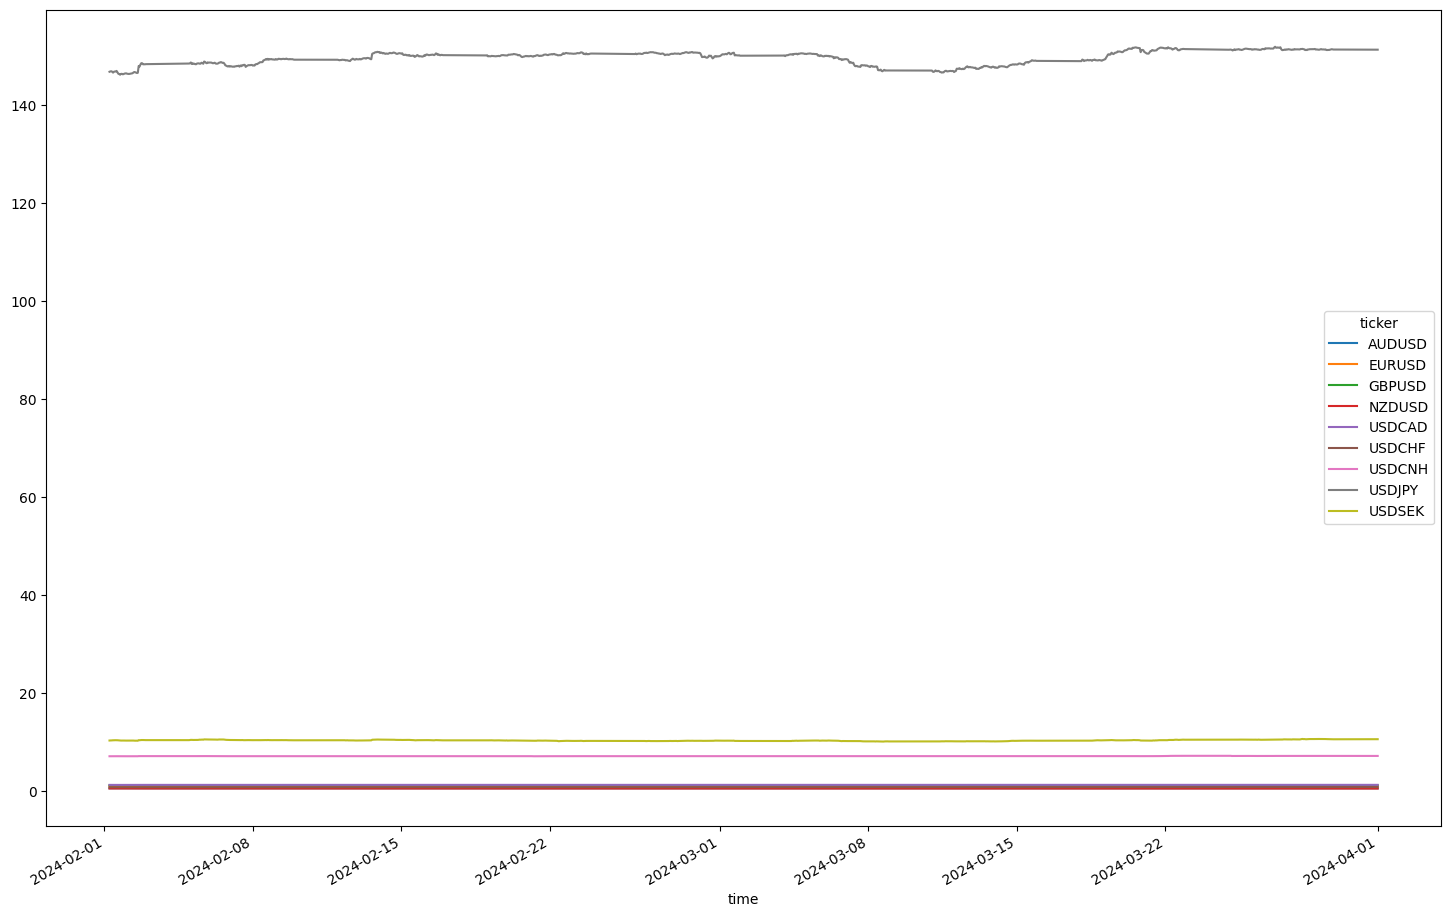

In [23]:
dfc.plot(figsize=(18,12))

In [24]:
# normalizando...
dfcn = dfc - dfc.mean()
dfcn

ticker,AUDUSD,EURUSD,GBPUSD,NZDUSD,USDCAD,USDCHF,USDCNH,USDJPY,USDSEK
time,,,,,,,,,
2024-02-01 06:00:00,0.001215,-0.002328,0.001089,0.002002,-0.008172,-0.019506,-0.026741,-2.871565,-0.017603
2024-02-01 07:00:00,-0.000305,-0.002838,-0.000211,0.000662,-0.006932,-0.019046,-0.023661,-2.799565,-0.001213
2024-02-01 08:00:00,-0.000755,-0.003478,-0.000651,0.000282,-0.006392,-0.018806,-0.022221,-2.772565,0.005437
2024-02-01 09:00:00,-0.000785,-0.003778,-0.001471,-0.000078,-0.005792,-0.018566,-0.018771,-2.853565,0.006347
2024-02-01 10:00:00,-0.001565,-0.003928,-0.001741,-0.000948,-0.006712,-0.019896,-0.020721,-3.047565,0.042717
...,...,...,...,...,...,...,...,...,...
2024-03-29 19:00:00,-0.002005,-0.004308,-0.005011,-0.012168,0.002478,0.019354,0.041929,1.650435,0.266287
2024-03-29 20:00:00,-0.002095,-0.004208,-0.005251,-0.012118,0.002808,0.019604,0.041529,1.728435,0.261977
2024-03-29 21:00:00,-0.002025,-0.004008,-0.005101,-0.012238,0.002838,0.019244,0.041819,1.686435,0.257277


<Axes: xlabel='time'>

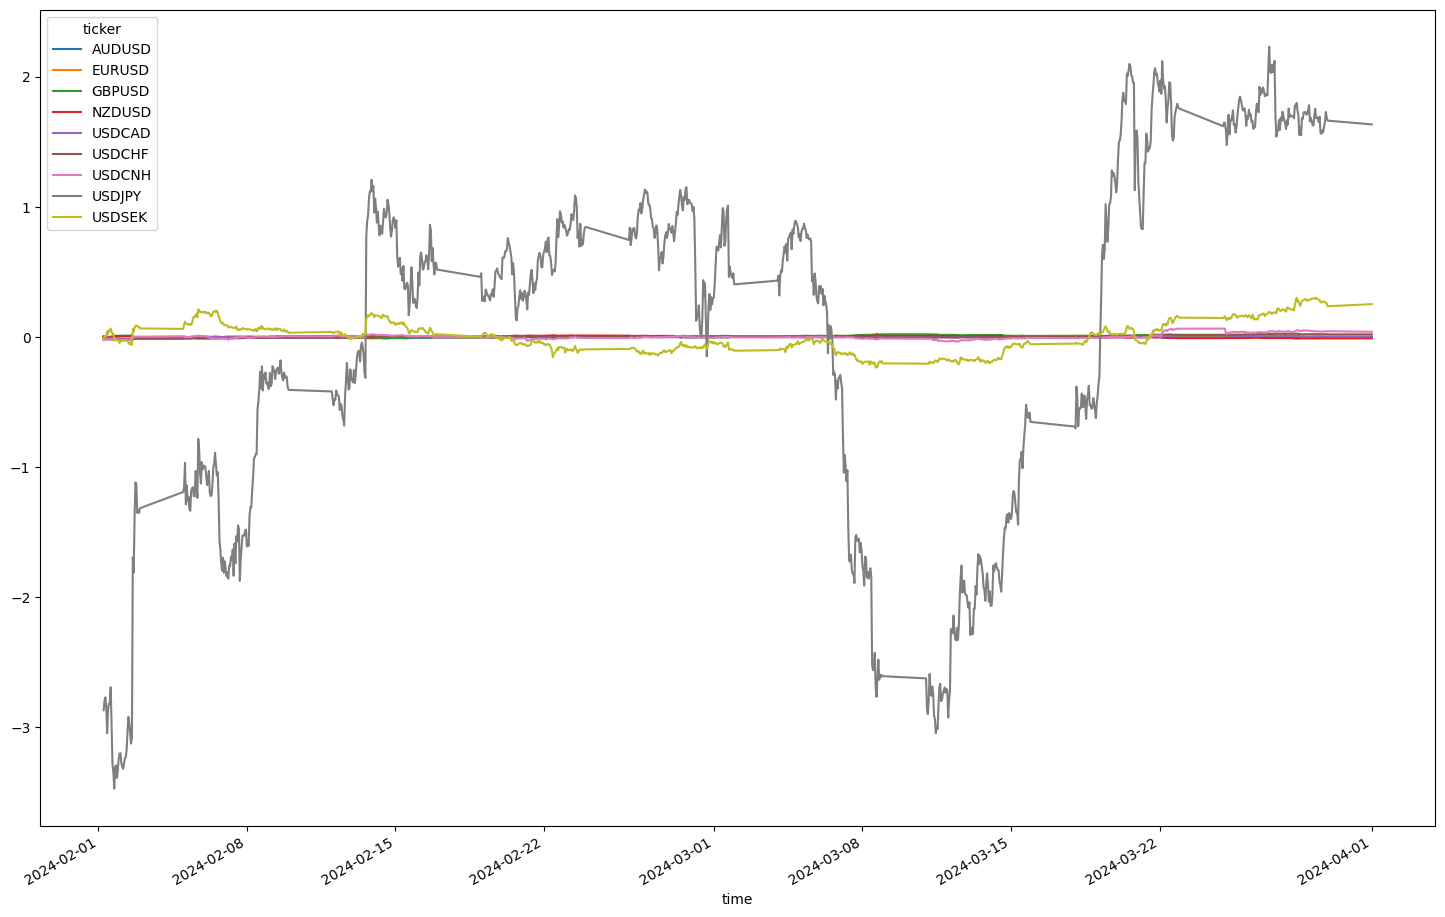

In [25]:
dfcn.plot(figsize=(18,12))

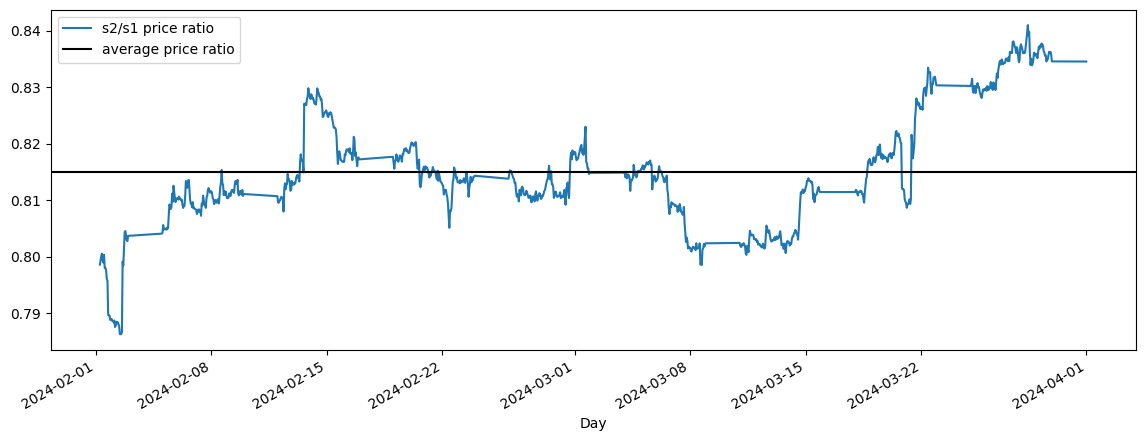

average price ratio 0.8149


In [26]:
s1 = dfc.EURUSD # dfc.BOVA11
s2 = dfc.USDCHF # dfc.WINQ22
price_ratio = s2/s1
price_ratio.plot(figsize=(14,5)) 
plt.axhline(price_ratio.mean(), color='black') 
plt.xlabel('Day')
plt.legend(['s2/s1 price ratio', 'average price ratio'])
plt.show()
print(f"average price ratio {price_ratio.mean():.4f}")

## Calculate hedge ratio with regression

## Linear Regression

Note that the LinearRegression().fit() expects 2D numpy arrays.  Since s1 and s2 are pandas series, we can use Series.values to get the values as a numpy array. Since these are 1D arrays, we can use numpy.reshape(-1,1) to make these 1000 row by 1 column 2 dimensional arrays


Observe que LinearRegression().fit() espera matrizes numpy 2D. Como s1 e s2 são séries pandas, podemos usar Series.values para obter os valores como uma matriz numpy. Como esses são arrays 1D, podemos usar numpy.reshape (-1,1) para tornar esses arrays bidimensionais de 1000 linhas por 1 coluna.

In [27]:
s1.values.reshape(-1,1).shape

(1000, 1)

In [28]:
lr = LinearRegression()
lr.fit(s1.values.reshape(-1,1),s2.values.reshape(-1,1))

LinearRegression()

In [29]:
hedge_ratio = lr.coef_[0][0]
hedge_ratio

-0.006294932855927741

In [31]:
intercept = lr.intercept_[0]
intercept

0.8894238408137822

In [32]:
print(f"hedge ratio from regression is {hedge_ratio:.4f}, intercept is {intercept:.4f}")

hedge ratio from regression is -0.0063, intercept is 0.8894


 ## Question
 Do you think we'll need the intercept when calculating the spread?  Why or why not?
 
 Você acha que precisaremos da interceptação ao calcular o spread? Por que ou por que não?

## Calculate the spread

In [33]:
spread = s2 - s1 * hedge_ratio

In [34]:
print(f"Average spread is {spread.mean()}")

Average spread is 0.8894238408137822


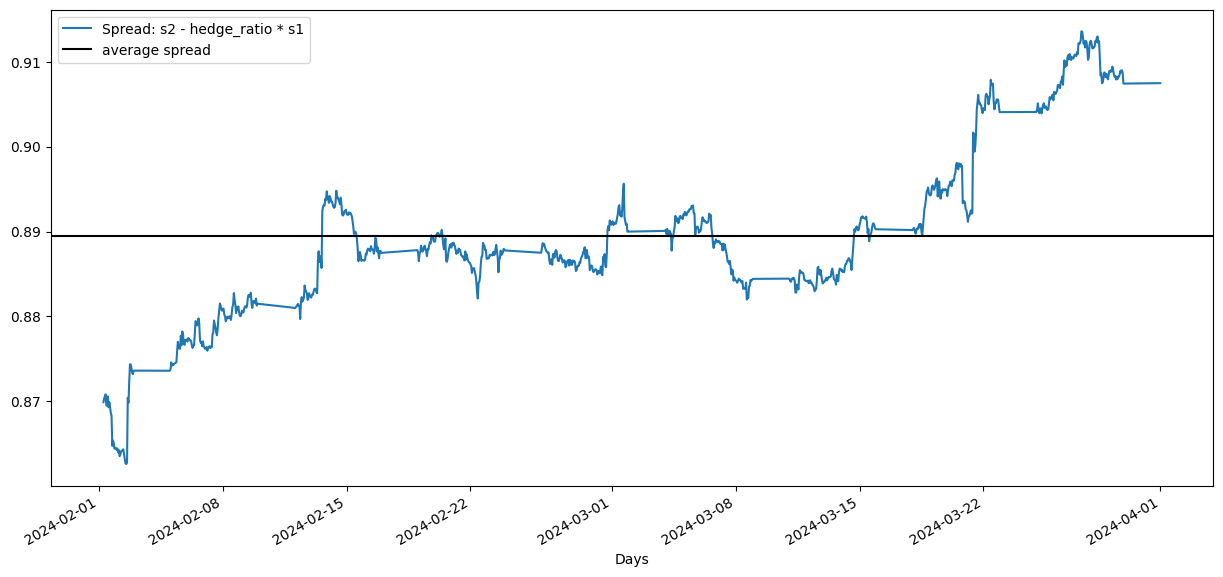

In [35]:
spread.plot(figsize=(15,7)) 
plt.axhline(spread.mean(), color='black') 
plt.xlabel('Days')
plt.legend(['Spread: s2 - hedge_ratio * s1', 'average spread'])
plt.show()

In [36]:
print(spread)

time
2024-02-01 06:00:00    0.869903
2024-02-01 07:00:00    0.870360
2024-02-01 08:00:00    0.870596
2024-02-01 09:00:00    0.870834
2024-02-01 10:00:00    0.869503
                         ...   
2024-03-29 19:00:00    0.908751
2024-03-29 20:00:00    0.909002
2024-03-29 21:00:00    0.908643
2024-03-29 22:00:00    0.907423
2024-04-01 00:00:00    0.907474
Length: 1000, dtype: float64


## Let's see what we get if we include the intercept of the regression

Vamos ver o que temos se incluirmos o intercepto da regressão

In [37]:
spread_with_intercept = s2 - (s1 * hedge_ratio + intercept)
print(f"Average spread with intercept included is {spread_with_intercept.mean()}")

Average spread with intercept included is 5.46229728115577e-17


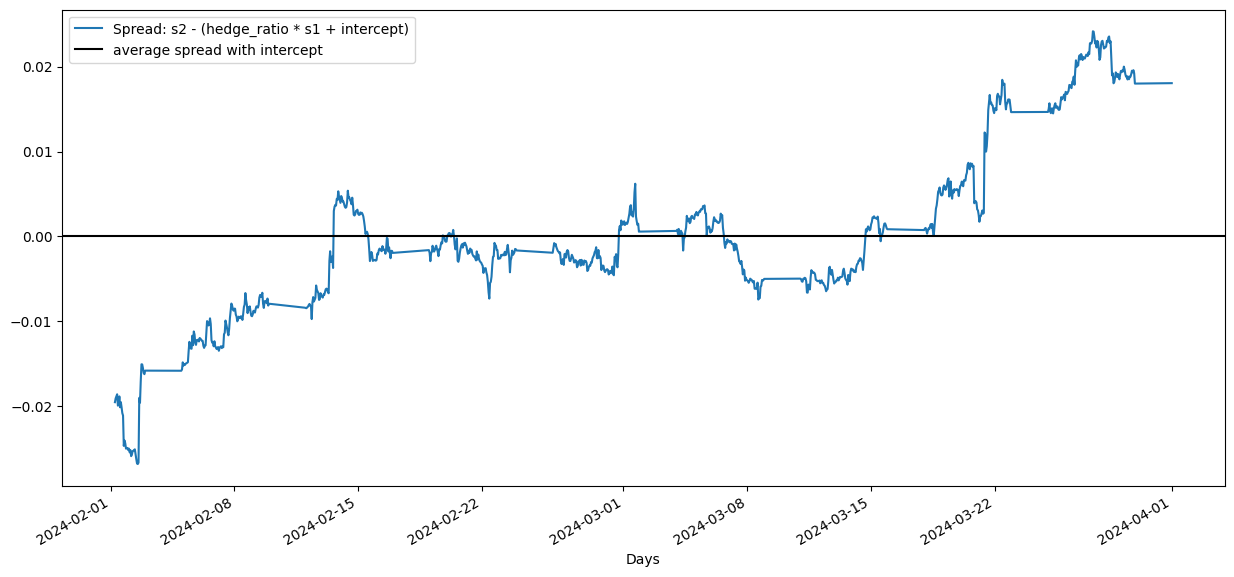

In [38]:
spread_with_intercept.plot(figsize=(15,7)) 
plt.axhline(spread_with_intercept.mean(), color='black') 
plt.xlabel('Days')
plt.legend(['Spread: s2 - (hedge_ratio * s1 + intercept)', 'average spread with intercept'])
plt.show()

## Quiz
### Check if spread is stationary using Augmented Dickey Fuller Test

The [adfuller](http://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html) function is part of the statsmodel library.

```
adfuller(x, maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)[source]

adf (float) – Test statistic
pvalue (float) – p-value
...
```

In [39]:
def is_spread_stationary(spread, p_level=0.05):
    """
    spread: obtained from linear combination of two series with a hedge ratio
    p_level: level of significance required to reject null hypothesis of non-stationarity
    
    returns:
        True if spread can be considered stationary
        False otherwise
    """
    #TODO: use the adfuller function to check the spread
    adf_result = adfuller(spread)
    
    #get the p-value
    pvalue = adf_result[1]
    
    if pvalue <= p_level:
        print(f"pvalue {pvalue:.12f} is <= {p_level}, assume spread is stationary")
        return True
    else:
        print(f"pvalue {pvalue:.12f} is > {p_level}, assume spread is not stationary")
        return False
    
#quiz_tests.test_is_spread_stationary(is_spread_stationary)

In [127]:
#analisar_long_short(dfc,"AERI3","ABEV3")

In [40]:
# Try out your function
print(f"Are the two series candidates for pairs trading? {is_spread_stationary(spread_with_intercept)}")

pvalue 0.596862722064 is > 0.05, assume spread is not stationary
Are the two series candidates for pairs trading? False


1. construa uma função () que recebe 2 series de precos e retorna o p-valor da razao entre as duas series.
2. 

In [41]:
def calc_edge_spread(s1,s2):
    #s1.values.reshape(-1,1).shape
    lr = LinearRegression()
    lr.fit(s1.values.reshape(-1,1),s2.values.reshape(-1,1))
    hedge_ratio = lr.coef_[0][0]
    intercept = lr.intercept_[0]
    spread = s2 - (s1 * hedge_ratio + intercept)
    return spread, intercept, hedge_ratio
            

In [42]:
# retorna o ultimo item do vetor
def get_ultimo(vetor):
    return vetor[ vetor.shape[0]-1 ]

In [43]:
def generate_long_short_candidates(dfc):
    # IN
    # dfc: DataFrame
    #   precos de fechamento por data e ativo
    #
    # OUT
    # dfls: DataFrame
    #   cada linha é um par de ativos com seu resultado do seu teste de estacionariedade
    #
    long_short = []
    for name1,data1 in dfc.dropna().items():
        print("Testando",name1, "...")
        for name2,data2 in dfc.dropna().items():

            if name1 != name2:
                # calculando o edge spread...
                spread,intercept,hedge_ratio = calc_edge_spread(data1,data2)
                #spread = data1/data2

                # calculando a estacionariedade do spread...
                adf_result = adfuller(spread)
                adf    = adf_result[0]
                pvalue = adf_result[1]

                # mantendo log na tela durante a execução...
                if pvalue <= 0.05:
                    long_short.append( [ name1,name2,adf,pvalue,intercept,hedge_ratio,spread.std(), get_ultimo(spread) ] )
                    #print(name1, name2, adf, pvalue)

    return pd.DataFrame(long_short, columns=['ticker1','ticker2','adf','pvalue','intercept','hedge_ratio','std','spread_atual' ])


In [44]:
long_short = generate_long_short_candidates(dfc)

Testando AUDUSD ...
Testando EURUSD ...


C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]
C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]
C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]


Testando GBPUSD ...


C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]
C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]
C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]


Testando NZDUSD ...


...

C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]
C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]
C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]


Testando USDJPY ...


C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]


Testando USDSEK ...


C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]
C:\Users\marco\AppData\Local\Temp\ipykernel_13940\664918874.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return vetor[ vetor.shape[0]-1 ]


In [45]:
#dfc.plot(figsize=(14,6))
#long_short.to_csv  ("long_short_b3_m1.csv")
#long_short.to_excel("long_short_b3_m1.xlsx")
long_short.to_excel("pairs_candidate.xlsx")

In [46]:
def plot_symbols(dfc,str1,str2,shift1=1,shift2=1):
    s1 = dfc[str1]*shift1
    s2 = dfc[str2]*shift2
    s1.name = str1
    s2.name = str2
    pd.concat([s1, s2], axis=1).plot(figsize=(15,4))
    plt.show()

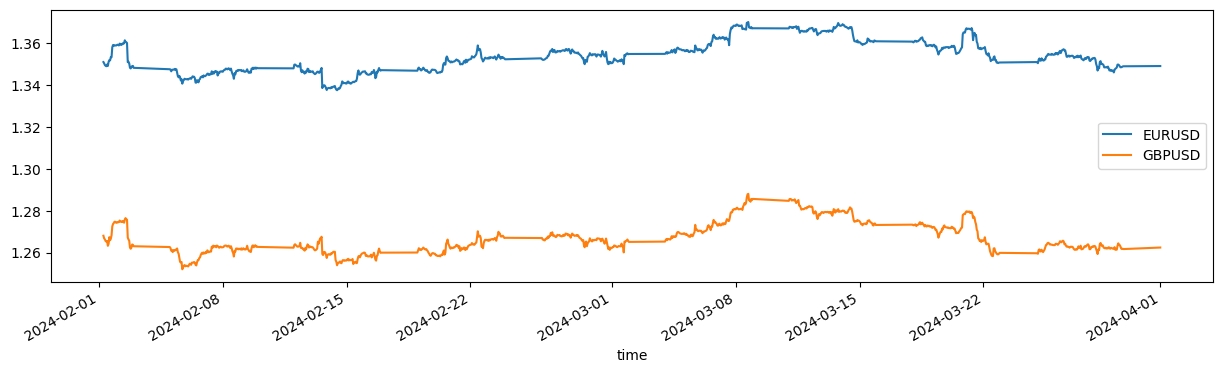

In [59]:
plot_symbols(dfc,"EURUSD","GBPUSD",1.25,1)

In [60]:
def plot_spread(spread,ativo1,ativo2):
    
    mean = spread.mean()
    std  = spread.std()
    zscore = ( ( spread - mean )/ std )
    
    print("std:",std)

    spread.name = "spread"
    zscore.name = "zscore"
    #pd.concat([spread, zscore], axis=1).plot(figsize=(14,5))
    spread.plot(figsize=(15,4))

    plt.axhline(mean  , color='black') 
    plt.axhline(std   , color='blue' ) 
    plt.axhline(-std  , color='blue' ) 
    plt.axhline(std*2   , color='red' ) 
    plt.axhline(-std*2  , color='red' ) 
    plt.xlabel('Days')
    #plt.legend([f'Spread: {ativo2} - hedge_ratio * {ativo1}', 'zscore','average spread','std','-std'])
    plt.legend([f'Spread: {ativo2} - hedge_ratio * {ativo1}','average spread','std','-std'])
    plt.show()

    #zscore.plot(figsize=(15,4))
    #plt.axhline( zscore.mean() , color='black') 
    #plt.axhline( zscore.std()  , color='blue' ) 
    #plt.axhline(-zscore.std()  , color='blue' ) 
    #plt.axhline( zscore.std()*2  , color='red' ) 
    #plt.axhline(-zscore.std()*2  , color='red' ) 
    #plt.legend(['zscore'])
    #plt.show()


In [61]:
def analisar_long_short(dfc,ativo1,ativo2, shift1=1,shift2=1):
    spread,intercept,hedge_ratio = calc_edge_spread( dfc[ativo1],dfc[ativo2] )
    plot_symbols(dfc,ativo1,ativo2,hedge_ratio,shift2)
    plot_spread(spread,ativo1,ativo2)
    coint = is_spread_stationary(spread)
    if coint:
        print(f"{ativo1} e {ativo2} são cointegrados. hedge_ratio:{hedge_ratio}")
    else:
        print(f"{ativo1} e {ativo2} NÃO são cointegrados.")


In [62]:
def analisar_long_short2(ativo1,ativo2,ano,mes,dia,qtd,timeframe=mt5.TIMEFRAME_M15,verbose=True):
    
    #obtendo os dados na corretora...
    df1=get_all_ticker_data([ativo1,ativo2], ano,mes,dia,qtd, timeframe,verbose)
    
    #organizando para ficar com indice por data e duas colunas cada uma com o preco de fechamento de um ativo...
    df1c = df1.pivot(index='time', columns='ticker', values='close').dropna()
    if verbose: print(df1c)
    
    # emitindo a analise...
    analisar_long_short(df1c,ativo1,ativo2,shift1=1,shift2=1)



Obtendo EURUSD 1 de 2 ...
Obtendo GBPUSD 2 de 2 ...
ticker       EURUSD   GBPUSD
time                        
2020-05-29  1.11076  1.23509
2020-06-01  1.11343  1.24874
2020-06-02  1.11685  1.25492
2020-06-03  1.12333  1.25713
2020-06-04  1.13365  1.25932
...             ...      ...
2024-03-27  1.08262  1.26338
2024-03-28  1.07881  1.26191
2024-03-29  1.07917  1.26167
2024-04-01  1.07422  1.25506
2024-04-02  1.07687  1.25768

[1000 rows x 2 columns]


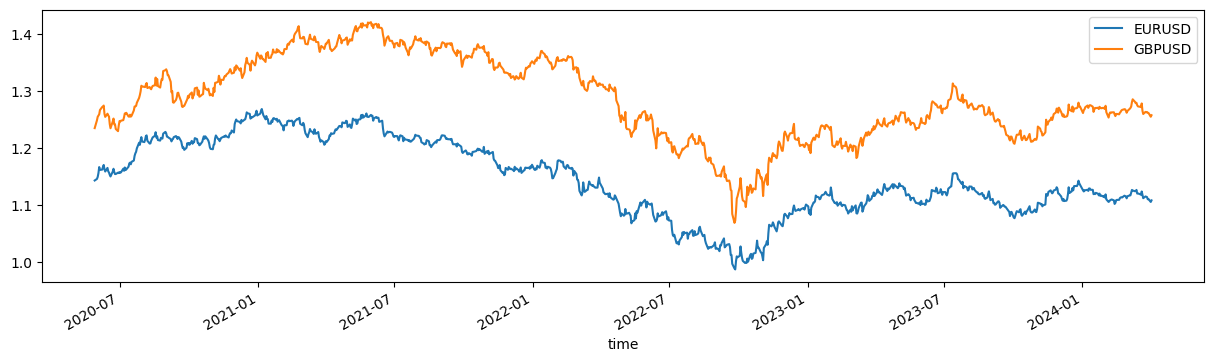

std: 0.02986554062490381


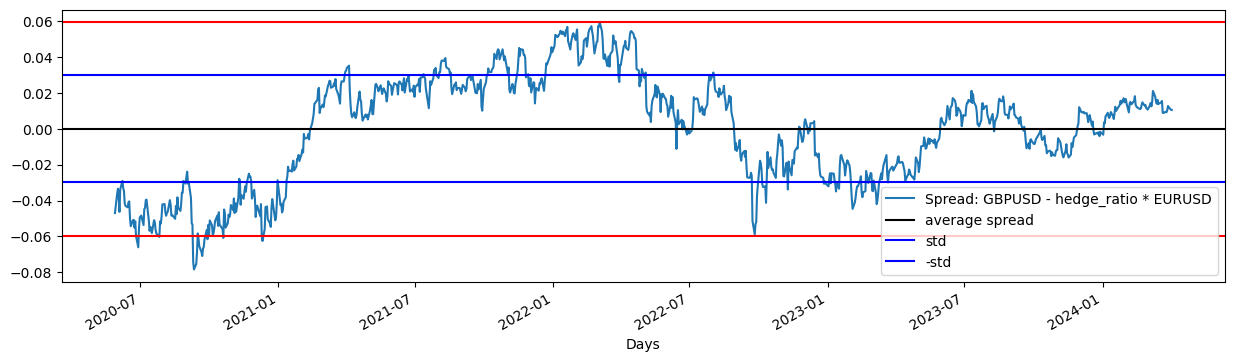

pvalue 0.218345154226 is > 0.05, assume spread is not stationary
EURUSD e GBPUSD NÃO são cointegrados.


In [71]:
#analisar_long_short(dfc,"BOVA11","WING21",1035,1)
#analisar_long_short(dfc,"PETR3" ,"CCRO3" ,1   ,2.4)
#analisar_long_short(dfc,"WDOH21","WING21",22.3,1)
#analisar_long_short(dfc,"HAPV3","CASH3",1.9,1)
#analisar_long_short(dfc,"MGLU3","CIEL3",1,6.15)
#analisar_long_short(dfc,"PETR4","BIDI4",1.70,1)
#analisar_long_short(dfc,"CIEL3","INDG21",29000,1)
#analisar_long_short(dfc,"CESP6","VVAR3",1,2.05)     #pvalor=0.009
#analisar_long_short(dfc,"INTB3","BRKM5",1.45,1)      #pvalor=0.005
#analisar_long_short(dfc,"ABEV3","RENT3",5,1)      #pvalor=0.005
#analisar_long_short(dfc,"HBSA3","MOVI3",4.24,1)      #pvalor=0.005
# analisar_long_short2("EURUSD","AUDUSD",2024,4,2,500,mt5.TIMEFRAME_D1)      #pvalor=0.005
# analisar_long_short2("EURUSD","USDCAD",2024,4,2,1000,mt5.TIMEFRAME_D1)      #pvalor=0.005
analisar_long_short2("EURUSD","GBPUSD",2024,4,2,1000,mt5.TIMEFRAME_D1)      #pvalor=0.005
